# ThinkLab NLP Project

## Product Review Sentiment Classification

**Member:** Buddhisha  
**Machine Learning Model:** Logistic Regression  
**Deep Learning Model:** LSTM

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

In [3]:
uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


In [4]:
filename = next(iter(uploaded))

dataset = pd.read_csv(filename)

print("Dataset loaded successfully")
print("Dataset shape:", dataset.shape)

dataset.head()

Dataset loaded successfully
Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
print("Dataset information:")
dataset.info()

print("\nMissing values in each column:")
print(dataset.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB

Missing values in each column:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Tit

In [5]:
# Select required columns
data = dataset[['Review Text', 'Rating']].copy()

print("Original records:", data.shape[0])

# Remove missing values
data = data.dropna(subset=['Review Text', 'Rating'])
print("After removing missing values:", data.shape[0])

# Remove duplicates
data = data.drop_duplicates()
print("After removing duplicates:", data.shape[0])

print("\nMissing values after cleaning:")
print(data.isnull().sum())

data.head()

Original records: 23486
After removing missing values: 22641
After removing duplicates: 22634

Missing values after cleaning:
Review Text    0
Rating         0
dtype: int64


,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5


In [6]:
# Create sentiment labels
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

data['Sentiment'] = data['Rating'].apply(create_sentiment)

data[['Review Text', 'Rating', 'Sentiment']].head(10)

,Review Text,Rating,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Positive
1,Love this dress! it's sooo pretty. i happene...,5,Positive
2,I had such high hopes for this dress and reall...,3,Neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Positive
4,This shirt is very flattering to all due to th...,5,Positive
5,"I love tracy reese dresses, but this one is no...",2,Negative
6,I aded this in my basket at hte last mintue to...,5,Positive
7,"I ordered this in carbon for store pick up, an...",4,Positive
8,I love this dress. i usually get an xs but it ...,5,Positive
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,Positive


In [ ]:
# Check the rating and sentiment mapping
print(
    data[['Rating', 'Sentiment']]
    .drop_duplicates()
    .sort_values('Rating')
)

    Rating Sentiment
61       1  Negative
5        2  Negative
2        3   Neutral
0        4  Positive
1        5  Positive


In [ ]:
# Count reviews in each sentiment class
sentiment_counts = data['Sentiment'].value_counts()

print("Each sentiment class counts:")
print(sentiment_counts)

Each sentiment class counts:
Sentiment
Positive    17442
Neutral      2823
Negative     2369
Name: count, dtype: int64


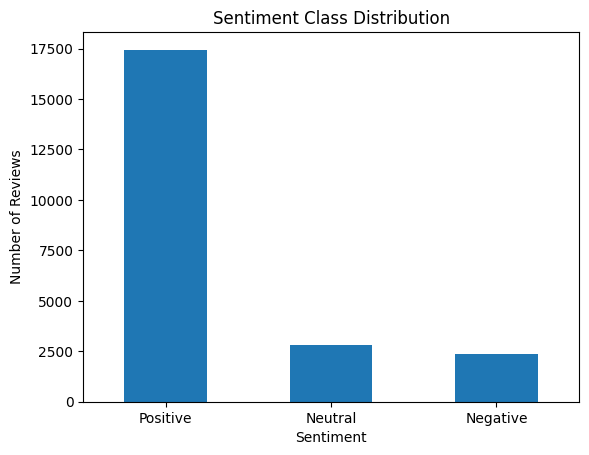

In [ ]:
# Display sentiment class distribution
sentiment_counts.plot(kind='bar')

plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Calculate the number of words in each review
data['Review Length'] = data['Review Text'].str.split().str.len()

print("Review length summary:")
print(data['Review Length'].describe())

Review length summary:
count    22634.000000
mean        60.199214
std         28.533191
min          2.000000
25%         36.000000
50%         59.000000
75%         88.000000
max        115.000000
Name: Review Length, dtype: float64


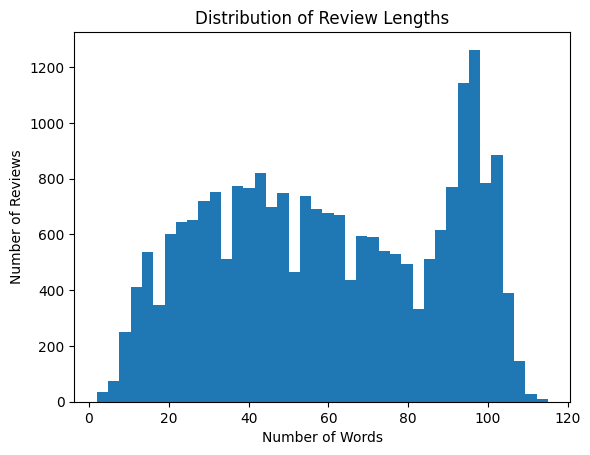

In [ ]:
# Review length distribution
data['Review Length'].plot(kind='hist', bins=40)

plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.show()

In [7]:
data.head()

,Review Text,Rating,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Positive
1,Love this dress! it's sooo pretty. i happene...,5,Positive
2,I had such high hopes for this dress and reall...,3,Neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Positive
4,This shirt is very flattering to all due to th...,5,Positive


In [8]:
import re

# Clean review text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['Cleaned Review'] = data['Review Text'].apply(clean_text)

data[['Review Text', 'Cleaned Review']].head(10)

,Review Text,Cleaned Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",i m and lbs i ordered the s petite to make sur...


In [9]:
# Check for empty reviews after cleaning
empty_reviews = (data['Cleaned Review'].str.len() == 0).sum()

print("Empty reviews after cleaning:", empty_reviews)

Empty reviews after cleaning: 0


In [10]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [11]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Prepare stop words and lemmatizer
stop_words = set(stopwords.words('english'))

# Keep important negative words for sentiment analysis
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')

lemmatizer = WordNetLemmatizer()


def process_text(text):
    # Tokenization
    words = text.split()

    # Remove stop words and apply lemmatization
    processed_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(processed_words)


data['Processed Review'] = data['Cleaned Review'].apply(process_text)

data[['Review Text', 'Cleaned Review', 'Processed Review']].head(10)

,Review Text,Cleaned Review,Processed Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...,love dress sooo pretty happened find store gla...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...,high hope dress really wanted work initially o...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...,love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...,love tracy reese dress one not petite foot tal...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...,aded basket hte last mintue see would look lik...
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...,ordered carbon store pick ton stuff always try...
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...,love dress usually get x run little snug bust ...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",i m and lbs i ordered the s petite to make sur...,lb ordered petite make sure length long typica...


In [12]:
# Check for empty processed reviews
empty_processed_reviews = (
    data['Processed Review'].str.strip() == ''
).sum()

print("Empty processed reviews:", empty_processed_reviews)

Empty processed reviews: 0


In [13]:
from sklearn.model_selection import train_test_split

# Select input text and target sentiment
X = data['Processed Review']
y = data['Sentiment']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", X_train.shape[0])
print("Testing reviews:", X_test.shape[0])

Training reviews: 18107
Testing reviews: 4527
